#  Root-Zone Soil Moisture (RZSM) Over India (1981–2024)
### *Data Processing, Spatial Subsetting, and Time-Series Extraction*

---

### Overview
This notebook demonstrates how to efficiently load, process, clip, and analyze high-resolution **Root-Zone Soil Moisture (RZSM)** data across India. 

* **Original Paper & Dataset:** [Nature Scientific Data (DOI: 10.1038/s41597-026-06940-x)](https://doi.org/10.1038/s41597-026-06940-x)
* **Temporal Coverage:** 1981–2024 (Daily)
* **Spatial Extent:** India / South Asia Domain

This repository is shared openly to help researchers, students, and practitioners access and analyze the dataset with ease.


## Preparing Region Of Interest

### Extracting region of interest from a state boundary file

In [116]:
import geopandas as gpd

# 1. Load the shapefile for my state of Interest
punjab = gpd.read_file(r'D:\Punjab_Project\Punjab_Project\PB_shapefiles\pb_districts.shp')

# 2. Inspecting the attribute table first — confirm it's district-level,
#    and find the exact column name + spelling used for district names
print(punjab.columns)

Index(['District', 'STATE', 'REMARKS', 'State_LGD', 'DISTRICT_L', 'Shape_Leng',
       'Shape_Area', 'id', 'geometry'],
      dtype='str')


EPSG:4326


<Axes: >

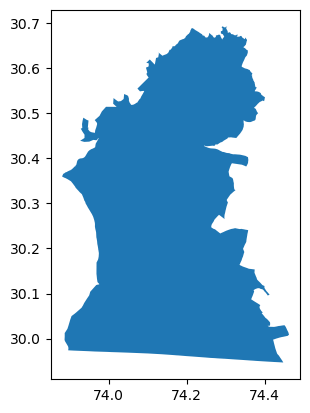

In [117]:
# 3. Filter to Fazilka or your district of choice
fazilka = punjab[punjab['District'] == 'FAZILKA'] 

print(fazilka.crs)

# 4. Plot to visually confirm you got the right district
fazilka.plot()

# 5. Save it as a shapefile for reuse across the workflow
fazilka.to_file('fazilka_boundary.shp')

## Exploring the Root Zone Soil Moisture Dataset

In [2]:
import xarray as xr
import rioxarray
import geopandas as gpd

ds = xr.open_dataset('RF_predcited_RZSM_1981_2024.nc', chunks={})
ds = ds.rio.write_crs('EPSG:4326')

In [80]:
ds

<xarray.Dataset> Size: 24GB
Dimensions:      (time: 16071, lat: 618, lon: 598)
Coordinates:
  * time         (time) datetime64[ns] 129kB 1981-01-01 ... 2024-12-31
  * lat          (lat) float32 2kB 7.025 7.075 7.125 7.175 ... 37.78 37.83 37.88
  * lon          (lon) float32 2kB 68.03 68.07 68.12 68.18 ... 97.78 97.82 97.88
    spatial_ref  int64 8B 0
Data variables:
    RZSM         (time, lat, lon) float32 24GB dask.array<chunksize=(1340, 52, 50), meta=np.ndarray>

In [3]:
# 1. Read the saved district shapefile saved in earlier steps
gdf = gpd.read_file("fazilka_boundary.shp")

# 2. slice the spatial bounding box
minx, miny, maxx, maxy = gdf.total_bounds

# (lat is ascending in our dataset: 7.025 to 37.88)
ds_sub = ds.sel(
    lat=slice(miny, maxy),
    lon=slice(minx, maxx)
)

# 3. Explicitly set CRS and spatial dimensions DIRECTLY on the sliced object
ds_sub = ds_sub.rio.write_crs("EPSG:4326")
ds_sub = ds_sub.rio.set_spatial_dims(x_dim="lon", y_dim="lat", inplace=True)

# 4. Perform the polygon clip
ds_clipped = ds_sub.rio.clip(gdf.geometry, gdf.crs, drop=True)

In [85]:
ds_clipped

<xarray.Dataset> Size: 11MB
Dimensions:      (lon: 11, lat: 15, time: 16071)
Coordinates:
  * lon          (lon) float32 44B 73.93 73.97 74.03 74.07 ... 74.32 74.38 74.43
  * lat          (lat) float32 60B 29.98 30.02 30.08 30.12 ... 30.58 30.62 30.67
  * time         (time) datetime64[ns] 129kB 1981-01-01 ... 2024-12-31
    spatial_ref  int64 8B 0
Data variables:
    RZSM         (time, lat, lon) float32 11MB dask.array<chunksize=(1340, 9, 11), meta=np.ndarray>

## Plotting the Dataset 

### Plotting day-wise

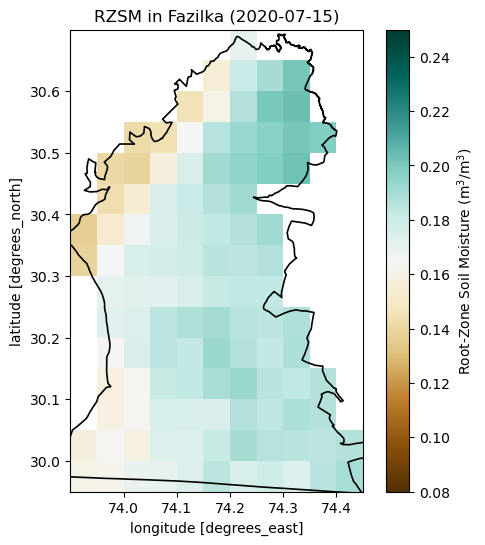

In [4]:
import matplotlib.pyplot as plt

# 1. Select the specific time and plot the 2D image
fig, ax = plt.subplots(figsize=(6, 6))

date = '2020-07-15'  # Pick any date between 1981 and 2024


# Using BrBG with explicit bounds for soil moisture (m³/m³)
p = ds_clipped['RZSM'].sel(time=date).plot(
    ax=ax,
    cmap='BrBG',          # Brown (dry) to Blue-Green (wet)
    vmin=0.08,            # Set a fixed lower bound suitable for your region
    vmax=0.25,            # Set a fixed upper bound
    cbar_kwargs={'label': r'Root-Zone Soil Moisture ($\mathrm{m^3/m^3}$)'}
)

# Overlay district boundary
gdf.boundary.plot(ax=ax, color='black', linewidth=1.2)

plt.title(f'RZSM in Fazilka ({date})')
plt.show()

### Plotting spatial average across a specific time range/period

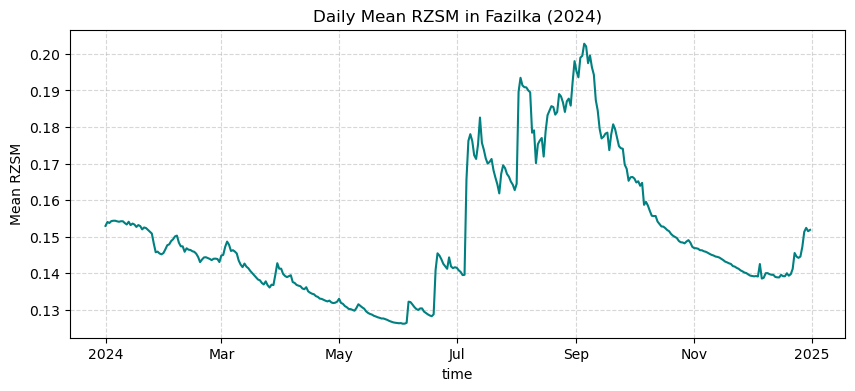

In [89]:
# Compute regional spatial mean across lat and lon
rzsm_mean = ds_clipped['RZSM'].mean(dim=['lat', 'lon'])

# Plot for a specific year or time range
fig, ax = plt.subplots(figsize=(10, 4))
rzsm_mean.sel(time=slice('2024-01-01', '2024-12-31')).plot(ax=ax, color='teal')

plt.title('Daily Mean RZSM in Fazilka (2024)')
plt.ylabel('Mean RZSM')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

### Downloading the time series for your region of interest as a csv

In [108]:
# 1. Our rzsm mean time series is still a DataArray we need it in a more suitable format
df_rzsm = rzsm_mean.to_dataframe(name="RZSM_mean")

# 2. (Optional) Reset index so 'time' becomes a regular column instead of an index
df_rzsm = df_rzsm.reset_index()

In [112]:
df_rzsm = df_rzsm.loc[:,['time','RZSM_mean']]   #dropping spatial_ref column 

In [113]:
df_rzsm.columns

Index(['time', 'RZSM_mean'], dtype='str')

In [114]:
# 3. Save to CSV
df_rzsm.to_csv("fazilka_rzsm_timeseries.csv", index=False)
# df_rzsm.drop('spatial_ref')
print("Saved CSV successfully! First few rows:")
print(df_rzsm.head())

Saved CSV successfully! First few rows:
        time  RZSM_mean
1 1981-01-02   0.140569
2 1981-01-03   0.139603
3 1981-01-04   0.140265
4 1981-01-05   0.142879
5 1981-01-06   0.143520


#### Recommended Resources & Acknowledgments
For further learning on geospatial Python, remote sensing, and multidimensional arrays, explore the following resources:

* **[Spatial Thoughts](https://spatialthoughts.com/)** by Ujaval Gandhi — Comprehensive open-access tutorials for GIS and geospatial Python.
* **[Prof. Qiusheng Wu](https://wetlands.io/)** — Outstanding open-source tools (such as `geolibre` and `leafmap`) and educational resources for geospatial analysis.
* **Author of Notebook / Contact:** [Zuhail Abdullah](https://www.linkedin.com/in/zuhail) *(Feel free to connect on LinkedIn for collaborations or queries).*




#### Contributing
Found a bug, want to optimize the code or have additional tutorials to recommend?  
**Pull Requests (PRs) and issues are welcome!** Feel free to fork the repository and submit your contributions.